      Name Department  Salary  Experience
0    alice         HR   50000           2
1      bob         IT   70000           5
2  charlie         IT   70000           4
3    david    Finance   60000           6
4      eva         HR   52000           3
5    frank    Finance   60000           6


<Axes: >

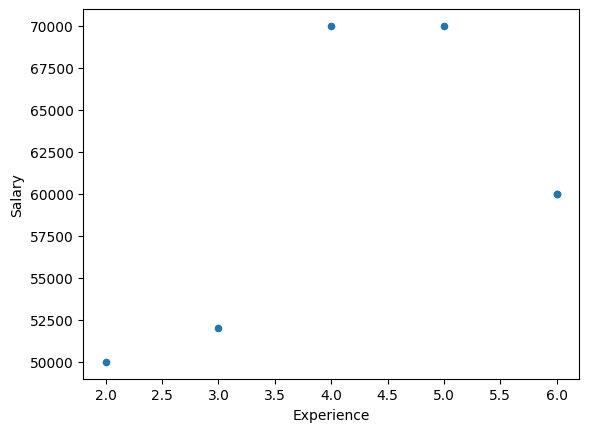

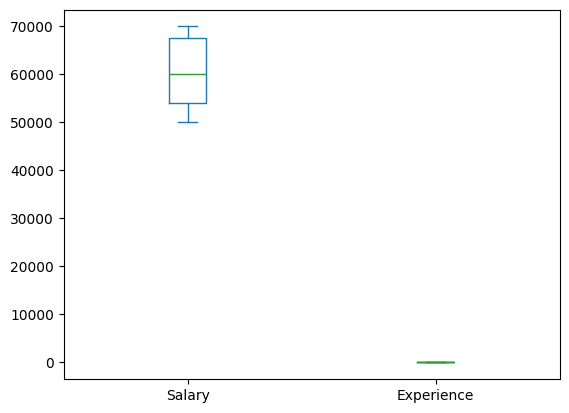

In [ ]:
import pandas as pd
import numpy as np
df=pd.DataFrame({
    'Name':['alice','bob','charlie','david','eva','frank'],
    'Department':['HR','IT','IT','Finance','HR','Finance'],
    'Salary':[50000,70000,70000,60000,52000,60000],
    'Experience':[2,5,4,6,3,6]
})
print(df)
#df[['Salary','Experience']].plot()
#df.plot(kind='bar',x='Name',y='Salary')
#df['Salary'].plot(kind='hist',bins=5)
df.plot(kind='scatter',x='Experience',y='Salary')
df[['Salary','Experience']].plot(kind='box')




In [ ]:
import pandas as pd
data={
    'Farm_ID':['F001','F002','F003','F004','F005','F006','F007'],
    'Crop':['wheat','rice','corn','wheat','rice','corn','wheat'],
    'Yields_Tons':[180,228,416,164,245,390,195],
    'Rainfall-mm':[450,820,680,420,850,710,480],
    'Fertilizer_kg':[120,150,200,110,160,195,125],
    'soil_pH':[6.5,5.8,6.2,6.7,5.9,6.1,6.4]

}
df=pd.DataFrame(data)
df['yield-per_ha']=(df['Yields_Tons']/50).round(1)
print('original Dataset:')
print(df)

print('\n===HIGH YIELD FARMS(>200tons)===')
high_yield=df[df['Yields_Tons']>200]
print(high_yield)

print('\n===RICE WITH HIGH RAINFALL(>800mm)===')
rice_high_grain=df[(df['Crop']=='rice')&(df['Rainfall-mm']>800)]
print(rice_high_grain)


print('\n===GRAIN CROPS (wheat&rice)===')
grain_crops=df[df['Crop'].isin(['wheat','rice'])]
print(grain_crops[['Farm_ID','Crop','Yields_Tons']])

print('\n===OPTIMAL SOIL pH(6.0 to 6.5)===')
Optimal_pH=df[df['soil_pH'].between(6.0 , 6.5)]
print(Optimal_pH[['Farm_ID','soil_pH','Yields_Tons']])


print('\n===COMPLEX QUERY:Good conditions===')
min_rainfall=600
good_conditions=df.query('`Rainfall-mm`>@min_rainfall and Fertilizer_kg>150')
print(good_conditions[['Farm_ID','Crop','Rainfall-mm','Fertilizer_kg']])

print('\n===FIRST 3 FARMS(iloc)===')
print(df.iloc[0:3])

print('\n===SPECIFIC COLUMNS(loc)===')
print(df.loc[:,['Farm_ID','Crop','yield-per_ha']])

print('\n===TOP PERFORMERS - SELECTED COLUMNS===')
top=df[df['yield-per_ha']>4.5][['Farm_ID','Crop','yield-per_ha']]
print(top)

original Dataset:
  Farm_ID   Crop  Yields_Tons  Rainfall-mm  Fertilizer_kg  soil_pH  \
0    F001  wheat          180          450            120      6.5   
1    F002   rice          228          820            150      5.8   
2    F003   corn          416          680            200      6.2   
3    F004  wheat          164          420            110      6.7   
4    F005   rice          245          850            160      5.9   
5    F006   corn          390          710            195      6.1   
6    F007  wheat          195          480            125      6.4   

   yield-per_ha  
0           3.6  
1           4.6  
2           8.3  
3           3.3  
4           4.9  
5           7.8  
6           3.9  

===HIGH YIELD FARMS(>200tons)===
  Farm_ID  Crop  Yields_Tons  Rainfall-mm  Fertilizer_kg  soil_pH  \
1    F002  rice          228          820            150      5.8   
2    F003  corn          416          680            200      6.2   
4    F005  rice          245        

In [ ]:
import pandas as pd
import numpy as np
data={'A':[1,np.nan,3,4,5],
      'B':[1,2,np.nan,4,5],
      'C':[np.nan,2,3,4,5],
      }
df=pd.DataFrame(data)
print('original DataFrame:')
df.dropna()


original DataFrame:


,A,B,C
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.dropna(axis=1)

""
0
1
2
3
4


In [ ]:
df.dropna(how='all')

,A,B,C
0,1.0,1.0,NaN
1,NaN,2.0,2.0
2,3.0,NaN,3.0
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.dropna(thresh=3)

,A,B,C
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.fillna(0)

,A,B,C
0,1.0,1.0,0.0
1,0.0,2.0,2.0
2,3.0,0.0,3.0
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.fillna(method='ffill')

/tmp/ipython-input-1193302488.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')


,A,B,C
0,1.0,1.0,NaN
1,1.0,2.0,2.0
2,3.0,2.0,3.0
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.fillna(method='bfill')

/tmp/ipython-input-2831856154.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill')


,A,B,C
0,1.0,1.0,2.0
1,3.0,2.0,2.0
2,3.0,4.0,3.0
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.ffill()

,A,B,C
0,1.0,1.0,NaN
1,1.0,2.0,2.0
2,3.0,2.0,3.0
3,4.0,4.0,4.0
4,5.0,5.0,5.0


In [ ]:
df.interpolate()

,A,B,C
0,1.0,1.0,NaN
1,2.0,2.0,2.0
2,3.0,3.0,3.0
3,4.0,4.0,4.0
4,5.0,5.0,5.0
